<a href="https://colab.research.google.com/github/Khushipawar37/mental_health_prediction/blob/main/mental_health_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Put correct file name here
file_path = "student_mental_health_burnout_1M.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ayeshasiddiqa123/student-health",
    file_path
)

print(df.head())

/tmp/ipykernel_6023/2202808354.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-health' dataset.
   age gender  academic_year  study_hours_per_day  exam_pressure  \
0   23   Male              2             5.596071       6.487218   
1   20   Male              3             5.597171       5.631481   
2   29   Male              2             2.580491       6.015297   
3   27   Male              4             4.607208       6.684005   
4   24   Male              4             2.186569       4.010945   

   academic_performance  stress_level  anxiety_score  depression_score  \
0             68.411114      4.116950       2.275713          1.986730   
1             67.682159      0.349489       0.000000          0.000000   
2             58.372363      3.476177       2.425201          0.851996   
3             68.925653      6.778843       4.512425          4.285645   
4             69.141915      1.854595       1.102558          0.000000   

   sleep_hours  physical_activity  social_support  screen_time  \
0     6.880

In [ ]:
target = "burnout_score"

burnout_score           1.000000
stress_level            0.753111
dropout_risk            0.689748
anxiety_score           0.668450
depression_score        0.642612
exam_pressure           0.434376
study_hours_per_day     0.335132
financial_stress        0.295702
family_expectation      0.217843
academic_performance    0.057089
academic_year           0.000555
age                    -0.001016
internet_usage         -0.001151
screen_time            -0.001215
physical_activity      -0.110074
social_support         -0.229811
sleep_hours            -0.371386
mental_health_index    -0.796527
Name: burnout_score, dtype: float64


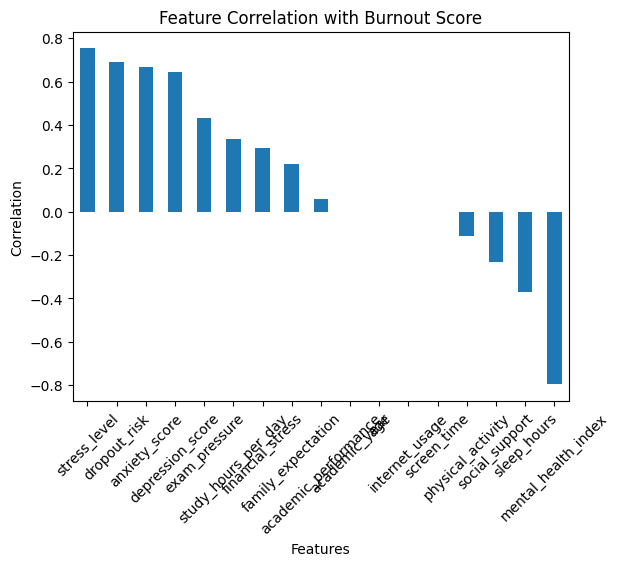

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Correlation with burnout_score
corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)

print(corr)

# Plot
plt.figure()
corr.drop(target).plot(kind='bar')
plt.title("Feature Correlation with Burnout Score")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

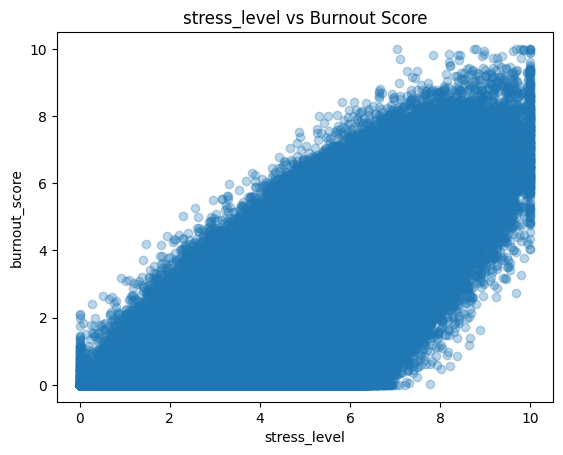

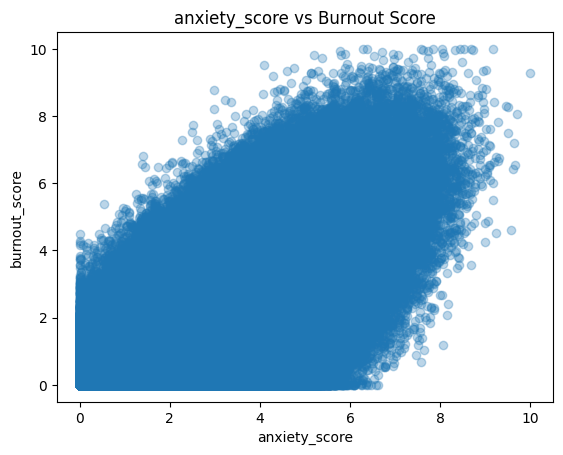

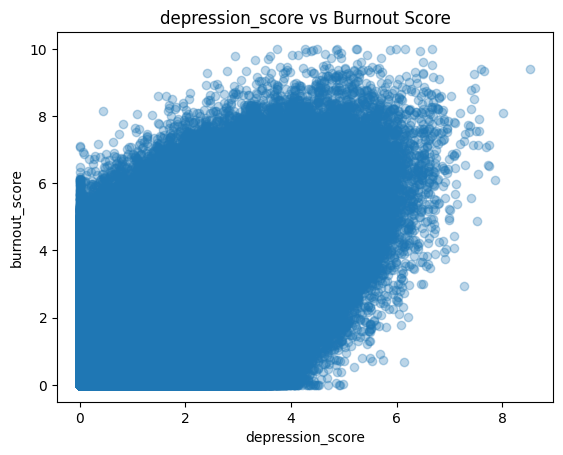

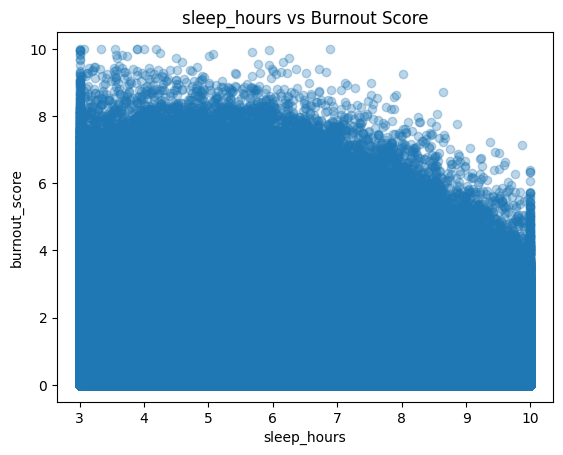

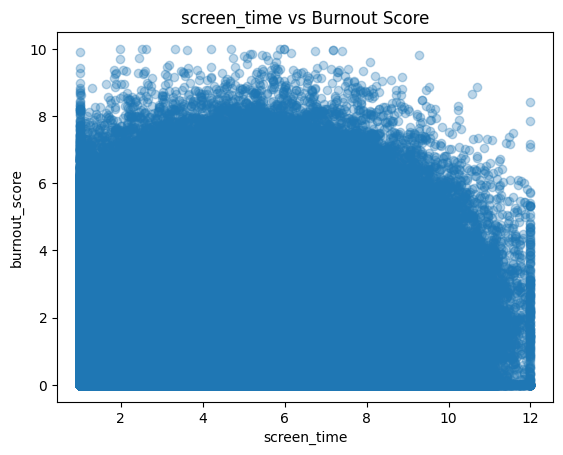

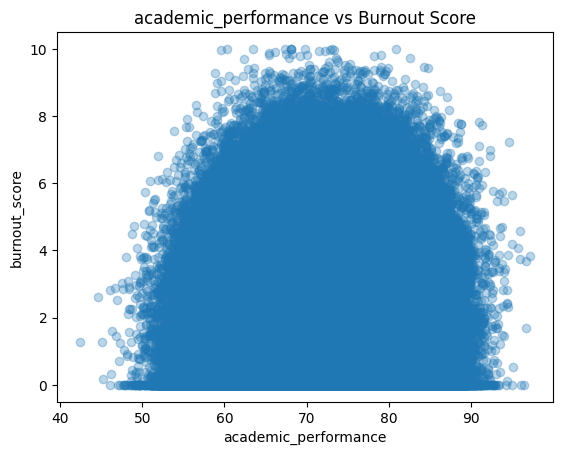

In [ ]:
features = [
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sleep_hours",
    "screen_time",
    "academic_performance"
]

for feature in features:
    plt.figure()
    plt.scatter(df[feature], df[target], alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel("burnout_score")
    plt.title(f"{feature} vs Burnout Score")
    plt.show()

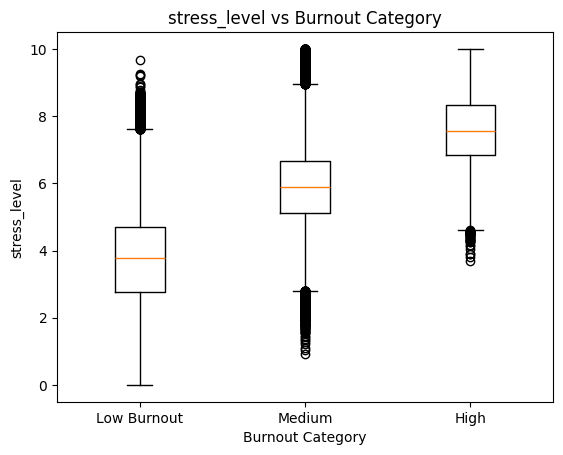

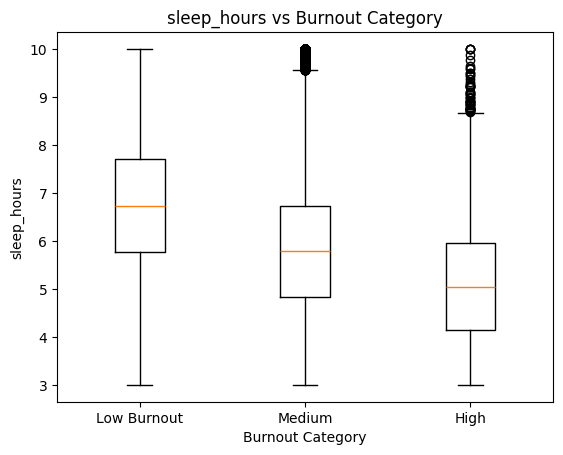

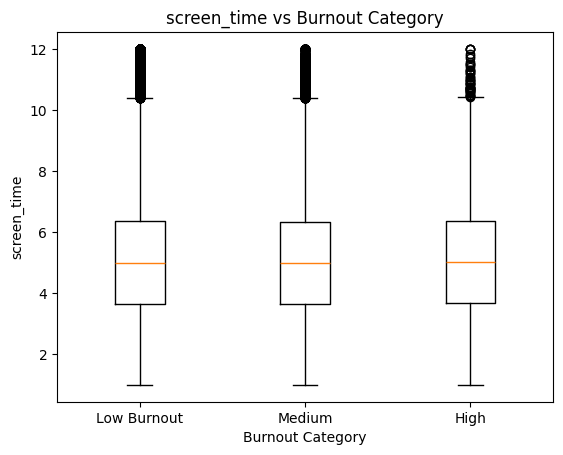

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# =============================
# 1. Drop leakage features
# =============================
df_clean = df.drop(["mental_health_index", "dropout_risk"], axis=1)

# =============================
# 2. Define X and y
# =============================
X = df_clean.drop("burnout_score", axis=1)
y = df_clean["burnout_score"]

# =============================
# 3. One-hot encode categorical
# =============================
X = pd.get_dummies(X, drop_first=True)

# =============================
# 4. Train-test split
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# 5. Train model
# =============================
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# =============================
# 6. Predict
# =============================
y_pred = model.predict(X_test)

# =============================
# 7. Evaluate
# =============================
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.504520702069143
R2 Score: 0.8469367778969411


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Assuming X and y already defined

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)

    return mae  # minimize MAE


# Run optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)  # increase to 50-100 for better results

print("Best Parameters:", study.best_params)

[I 2026-04-02 15:00:15,861] A new study created in memory with name: no-name-0c6da236-b76b-4a7d-881e-ceaa5b981b8c
[I 2026-04-02 15:01:01,805] Trial 0 finished with value: 0.5080875418043479 and parameters: {'n_estimators': 402, 'max_depth': 10, 'learning_rate': 0.09885421822292488, 'subsample': 0.9036481803568707, 'colsample_bytree': 0.9880348256727806, 'gamma': 0.18486488318480654, 'reg_alpha': 3.864551522279423, 'reg_lambda': 1.1328857200211473}. Best is trial 0 with value: 0.5080875418043479.
[I 2026-04-02 15:01:22,968] Trial 1 finished with value: 0.5051767397599964 and parameters: {'n_estimators': 586, 'max_depth': 10, 'learning_rate': 0.08086293544837786, 'subsample': 0.8568314756175417, 'colsample_bytree': 0.6454663938591719, 'gamma': 3.4888405132741407, 'reg_alpha': 3.9801117537385755, 'reg_lambda': 4.276053347735309}. Best is trial 1 with value: 0.5051767397599964.
[I 2026-04-02 15:01:56,063] Trial 2 finished with value: 0.5041693657238788 and parameters: {'n_estimators': 638,

Best Parameters: {'n_estimators': 505, 'max_depth': 10, 'learning_rate': 0.031010056289504633, 'subsample': 0.8429506211828475, 'colsample_bytree': 0.8081043292458306, 'gamma': 1.5161024368172689, 'reg_alpha': 3.398038914192915, 'reg_lambda': 1.5567822382795469}


In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model, X, y,
    scoring="neg_mean_absolute_error",
    cv=5
)

print("MAE:", -scores.mean())

MAE: 0.5040769780142484


In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# =============================
# 1. Load Data
# =============================
# df already loaded (skip if already done)
# df = pd.read_csv("your_file.csv")

# =============================
# 2. Drop Leakage Features
# =============================
df = df.drop(["mental_health_index", "dropout_risk"], axis=1)

# =============================
# 3. Feature Engineering
# =============================

# Interaction features
df["stress_anxiety"] = df["stress_level"] * df["anxiety_score"]

df["pressure_total"] = (
    df["exam_pressure"] + df["financial_stress"] + df["family_expectation"]
)

df["mental_health_risk"] = (
    df["depression_score"] + df["anxiety_score"] - df["social_support"]
)

df["lifestyle_score"] = (
    df["sleep_hours"] + df["physical_activity"] - df["screen_time"]
)

# Non-linear features
df["stress_squared"] = df["stress_level"] ** 2
df["sleep_inverse"] = 1 / (df["sleep_hours"] + 1)

# =============================
# 4. Remove Weak Features
# =============================
df = df.drop(["age", "internet_usage", "academic_year"], axis=1)

# =============================
# 5. Define X and y
# =============================
X = df.drop("burnout_score", axis=1)
y = df["burnout_score"]

# =============================
# 6. Encode Categorical Data
# =============================
X = pd.get_dummies(X, drop_first=True)

# =============================
# 7. Train-Test Split
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# 8. Train Model
# =============================
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =============================
# 9. Evaluate (Test Set)
# =============================
y_pred = model.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

# =============================
# 10. Cross Validation (Stability Check)
# =============================
scores = cross_val_score(
    model, X, y,
    scoring="neg_mean_absolute_error",
    cv=5
)

print("CV MAE:", -scores.mean())
print("CV Std:", scores.std())

Test MAE: 0.5042339886480095
Test R2: 0.8470575951657493
CV MAE: 0.5036015960016992
CV Std: 0.0005573335343318917
